# Cross-Session Comparison — Cheese Acidification

**Sessions:** 28 April 2026 & 5 May 2026  
**Authors:** Lilandra Albert-Lavault & Samuele Moungang  
**Supervisor:** Dimitri Bocquel

This notebook merges both experimental sessions to:
1. Compare corrected pH profiles (aligned to t = 0 = moulage)
2. Compare logistic decline parameters (L, k, t₀) and analyse quantitative differences between sessions
3. Evaluate whether the Luedeking-Piret ODE model fits the data well (residuals, R², parameter plausibility)
4. Interpret session differences in terms of culture ratio and bacterial activity

> **Note (prof. feedback):** With only 2 sessions, statistical correlations with quality indicators (yield, texture) are not meaningful. The focus is on characterising and explaining the **differences between S1 and S2**.

---
## 0. Setup & Constants

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import curve_fit, minimize
from scipy.integrate import solve_ivp
from scipy.signal import savgol_filter

plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 120,
                     'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Session metadata ──────────────────────────────────────────────────────
SESSIONS = {
    'S1': {
        'label':        'Session 1 — 28 Apr 2026',
        'color':        'seagreen',
        'yield_pct':    12.17,   # fresh yield from fiche
        'T0_moulage':   pd.Timestamp('2026-04-28 11:36:00'),
        'FW_START':     pd.Timestamp('2026-04-28 12:10:00'),
        'FW_END':       pd.Timestamp('2026-04-28 14:00:00'),
        'cultures':     'MFR38 (974g) + MFR32 (282g)  [ratio 3.45:1]',
    },
    'S2': {
        'label':        'Session 2 — 5 May 2026',
        'color':        'steelblue',
        'yield_pct':    11.80,
        'T0_moulage':   pd.Timestamp('2026-05-05 11:30:00'),  # estimated
        'FW_START':     pd.Timestamp('2026-05-05 11:30:00'),
        'FW_END':       pd.Timestamp('2026-05-05 15:15:00'),
        'cultures':     'MFR38 + MFR32 [ratio 1:2]',
    },
}

T_CAL = 25.0
PH_ISO = 7.0

def nernst_correct(pH_meas, T_meas_C, T_cal_C=T_CAL, pH_iso=PH_ISO):
    T_meas_K = T_meas_C + 273.15
    T_cal_K  = T_cal_C  + 273.15
    return pH_iso + (pH_meas - pH_iso) * (T_meas_K / T_cal_K)

print('Setup OK — Sessions:', list(SESSIONS.keys()))


Setup OK — Sessions: ['S1', 'S2']


---
## 1. Load & Preprocess Both Sessions

Reference probe: **Hannah** (has internal ATC → no Nernst correction needed).
USB and Server: Nernst correction applied with assumed T = 35 °C.


In [2]:
# ── Session 1 — Hannah (PHLOT001) ───────────────────────────────────────
h1_raw = pd.read_csv(
    'data/trace pH fromage 3_28042026_hannah.csv',
    skiprows=20, header=None,
    names=['_','rec','date','time','pH','u1','mV','u2','temp_C','u3','_2'],
    usecols=['date','time','pH','temp_C'], encoding='latin-1',
)
h1_raw['datetime'] = pd.to_datetime(
    h1_raw['date'].str.strip() + ' ' + h1_raw['time'].str.strip(), dayfirst=False)
h1_raw['pH'] = pd.to_numeric(h1_raw['pH'], errors='coerce')
h1_raw['temp_C'] = pd.to_numeric(h1_raw['temp_C'], errors='coerce')
h1 = h1_raw.set_index('datetime').sort_index()[['pH','temp_C']].dropna()
h1_res = h1['pH'].resample('1min').median().dropna()
# Hannah S1: ATC internal — no Nernst
pH_h1 = h1_res.copy()
print(f'Hannah S1: {len(pH_h1)} pts | pH {pH_h1.min():.3f}→{pH_h1.max():.3f} | {pH_h1.index[0].time()}→{pH_h1.index[-1].time()}')

# ── Session 2 — Hannah (PHLOT002) ───────────────────────────────────────
h2_raw = pd.read_csv('data_5_mai/trace_pH_hannah_05052026.csv', parse_dates=['datetime'])
h2 = h2_raw.set_index('datetime').sort_index()[['pH','temp_C']].dropna()
h2_res = h2['pH'].resample('1min').median().dropna()
# Hannah S2: ATC internal — no Nernst
pH_h2 = h2_res.copy()
print(f'Hannah S2: {len(pH_h2)} pts | pH {pH_h2.min():.3f}→{pH_h2.max():.3f} | {pH_h2.index[0].time()}→{pH_h2.index[-1].time()}')

# ── Align to t = 0 (moulage) ────────────────────────────────────────────
def align_to_t0(series, T0):
    """Convert datetime index to hours elapsed since T0."""
    return pd.Series(
        series.values,
        index=(series.index - T0).total_seconds() / 3600,
        name=series.name
    )

pH_h1_t = align_to_t0(pH_h1, SESSIONS['S1']['T0_moulage'])
pH_h2_t = align_to_t0(pH_h2, SESSIONS['S2']['T0_moulage'])
print('\nAligned to t=0 (moulage)')
print(f'S1 t range: {pH_h1_t.index[0]:.2f}h → {pH_h1_t.index[-1]:.2f}h')
print(f'S2 t range: {pH_h2_t.index[0]:.2f}h → {pH_h2_t.index[-1]:.2f}h')


Hannah S1: 251 pts | pH 5.020→6.040 | 12:08:00→16:18:00
Hannah S2: 286 pts | pH 5.150→6.420 | 11:23:00→16:08:00

Aligned to t=0 (moulage)
S1 t range: 0.53h → 4.70h
S2 t range: -0.12h → 4.63h


---
## 2. pH Profiles — Cross-Session Comparison (Hannah, aligned to t = 0)

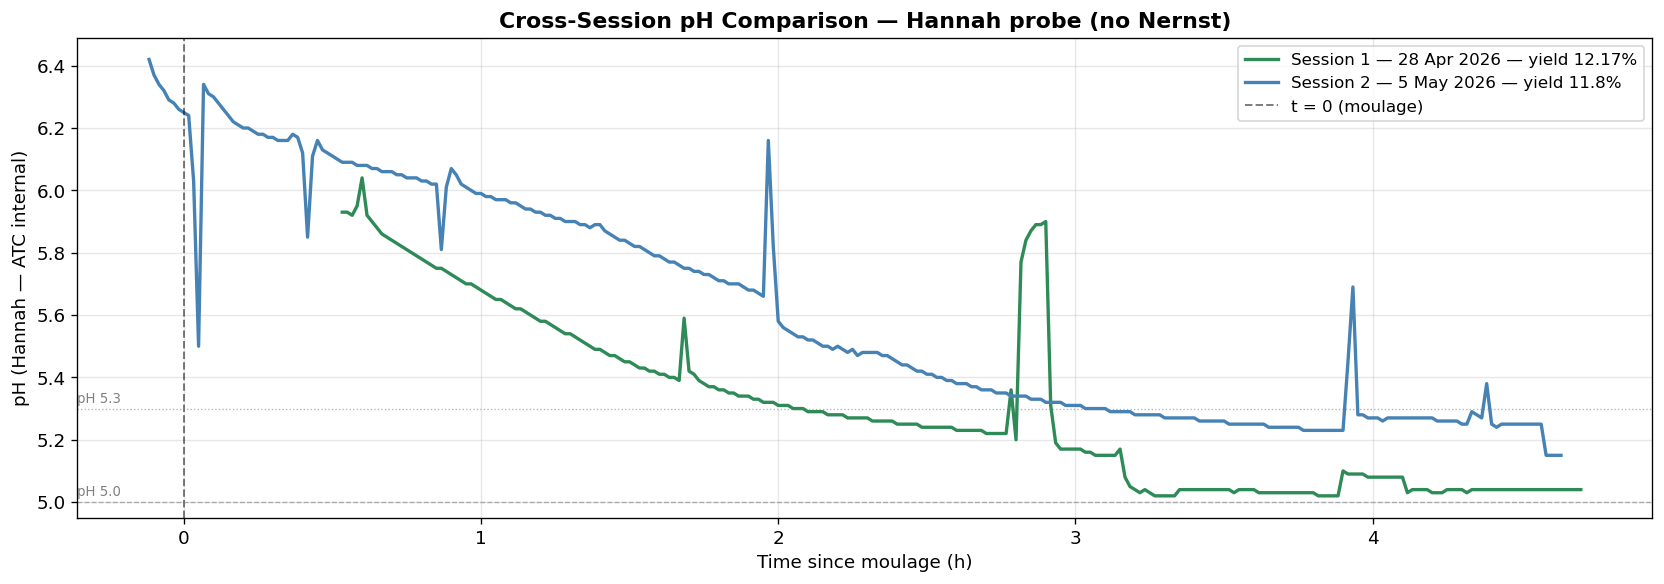

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(pH_h1_t.index, pH_h1_t.values,
        color=SESSIONS['S1']['color'], linewidth=2.0,
        label=f"{SESSIONS['S1']['label']} — yield {SESSIONS['S1']['yield_pct']}%")
ax.plot(pH_h2_t.index, pH_h2_t.values,
        color=SESSIONS['S2']['color'], linewidth=2.0,
        label=f"{SESSIONS['S2']['label']} — yield {SESSIONS['S2']['yield_pct']}%")

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.5, label='t = 0 (moulage)')

for th, ls in [(5.3, ':'), (5.0, '--')]:
    ax.axhline(th, color='grey', linewidth=0.8, linestyle=ls, alpha=0.6)
    ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] != 0 else -0.5,
            th + 0.02, f'pH {th}', fontsize=8, color='grey')

ax.set_xlabel('Time since moulage (h)')
ax.set_ylabel('pH (Hannah — ATC internal)')
ax.set_title('Cross-Session pH Comparison — Hannah probe (no Nernst)', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cmp_01_pH_profiles.png', bbox_inches='tight')
plt.show()


---
## 3. Key Features — Acidification Milestones

In [4]:
def extract_features(ph_t, label, yield_pct):
    """Extract key quantitative features from a pH-vs-time series (t in hours)."""
    ph = ph_t.dropna()
    # Rate of acidification
    dpH = np.gradient(ph.values, ph.index)
    max_rate_idx = np.argmin(dpH)   # most negative = fastest drop

    def first_below(threshold):
        mask = ph < threshold
        return round(ph.index[mask].min(), 2) if mask.any() else None

    return {
        'Session':          label,
        'Yield (%)':        yield_pct,
        'pH initial':       round(ph.iloc[0], 3),
        'pH final':         round(ph.iloc[-1], 3),
        'ΔpH total':        round(ph.iloc[0] - ph.iloc[-1], 3),
        't → pH 5.5 (h)':   first_below(5.5),
        't → pH 5.3 (h)':   first_below(5.3),
        't → pH 5.0 (h)':   first_below(5.0),
        'Max rate (pH/h)':  round(abs(dpH[max_rate_idx]), 4),
        't max rate (h)':   round(ph.index[max_rate_idx], 2),
    }

rows = [
    extract_features(pH_h1_t, SESSIONS['S1']['label'], SESSIONS['S1']['yield_pct']),
    extract_features(pH_h2_t, SESSIONS['S2']['label'], SESSIONS['S2']['yield_pct']),
]
feat_df = pd.DataFrame(rows).set_index('Session')
feat_df


,Yield (%),pH initial,pH final,ΔpH total,t → pH 5.5 (h),t → pH 5.3 (h),t → pH 5.0 (h),Max rate (pH/h),t max rate (h)
Session,,,,,,,,,
Session 1 — 28 Apr 2026,12.17,5.93,5.04,0.89,1.38,2.10,None,21.3,2.92
Session 2 — 5 May 2026,11.80,6.42,5.15,1.27,2.18,3.12,None,22.2,0.03


---
## 4. Logistic Decline Fit — Parameter Comparison

$$\mathrm{pH}(t) = L + \frac{\mathrm{pH}_0 - L}{1 + e^{k(t-t_0)}}$$

- **L** : asymptotic minimum pH (plateau)
- **pH₀** : initial pH at t = 0
- **k** : acidification rate constant (h⁻¹)
- **t₀** : inflection time (h after moulage)


In [5]:
def logistic_decline(t, L, pH0, k, t0):
    return L + (pH0 - L) / (1 + np.exp(k * (t - t0)))

def fit_logistic_t(ph_t, fw_start_h, fw_end_h):
    """Fit logistic on aligned (hours) series; return params + fit-window index."""
    mask  = (ph_t.index >= fw_start_h) & (ph_t.index <= fw_end_h)
    t_fit = ph_t.index[mask]
    y_fit = ph_t.values[mask]
    if len(t_fit) < 4:
        return None
    p0 = [y_fit.min(), y_fit.max(), 2.0, np.median(t_fit)]
    try:
        popt, pcov = curve_fit(logistic_decline, t_fit, y_fit, p0=p0, maxfev=10000)
        y_pred = logistic_decline(t_fit, *popt)
        ss_res = np.sum((y_fit - y_pred) ** 2)
        ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        perr = np.sqrt(np.diag(pcov))
        return dict(L=popt[0], pH0=popt[1], k=popt[2], t0=popt[3],
                    r2=r2, t_fit=t_fit, y_pred=y_pred, perr=perr)
    except Exception as e:
        print(f'Fit failed: {e}'); return None

# Convert FW timestamps to hours-since-moulage
def ts_to_h(ts, T0): return (ts - T0).total_seconds() / 3600

fit_h1 = fit_logistic_t(
    pH_h1_t,
    ts_to_h(SESSIONS['S1']['FW_START'], SESSIONS['S1']['T0_moulage']),
    ts_to_h(SESSIONS['S1']['FW_END'],   SESSIONS['S1']['T0_moulage'])
)
fit_h2 = fit_logistic_t(
    pH_h2_t,
    ts_to_h(SESSIONS['S2']['FW_START'], SESSIONS['S2']['T0_moulage']),
    ts_to_h(SESSIONS['S2']['FW_END'],   SESSIONS['S2']['T0_moulage'])
)

for key, fit, sess in [('S1', fit_h1, 'S1'), ('S2', fit_h2, 'S2')]:
    print(f"{SESSIONS[sess]['label']}:")
    print(f"  L={fit['L']:.3f}  pH0={fit['pH0']:.3f}  k={fit['k']:.3f}  t0={fit['t0']:.3f}  R²={fit['r2']:.3f}")


Session 1 — 28 Apr 2026:
  L=5.078  pH0=26.577  k=0.920  t0=-2.870  R²=0.987
Session 2 — 5 May 2026:
  L=5.196  pH0=6.218  k=1.693  t0=1.773  R²=0.957


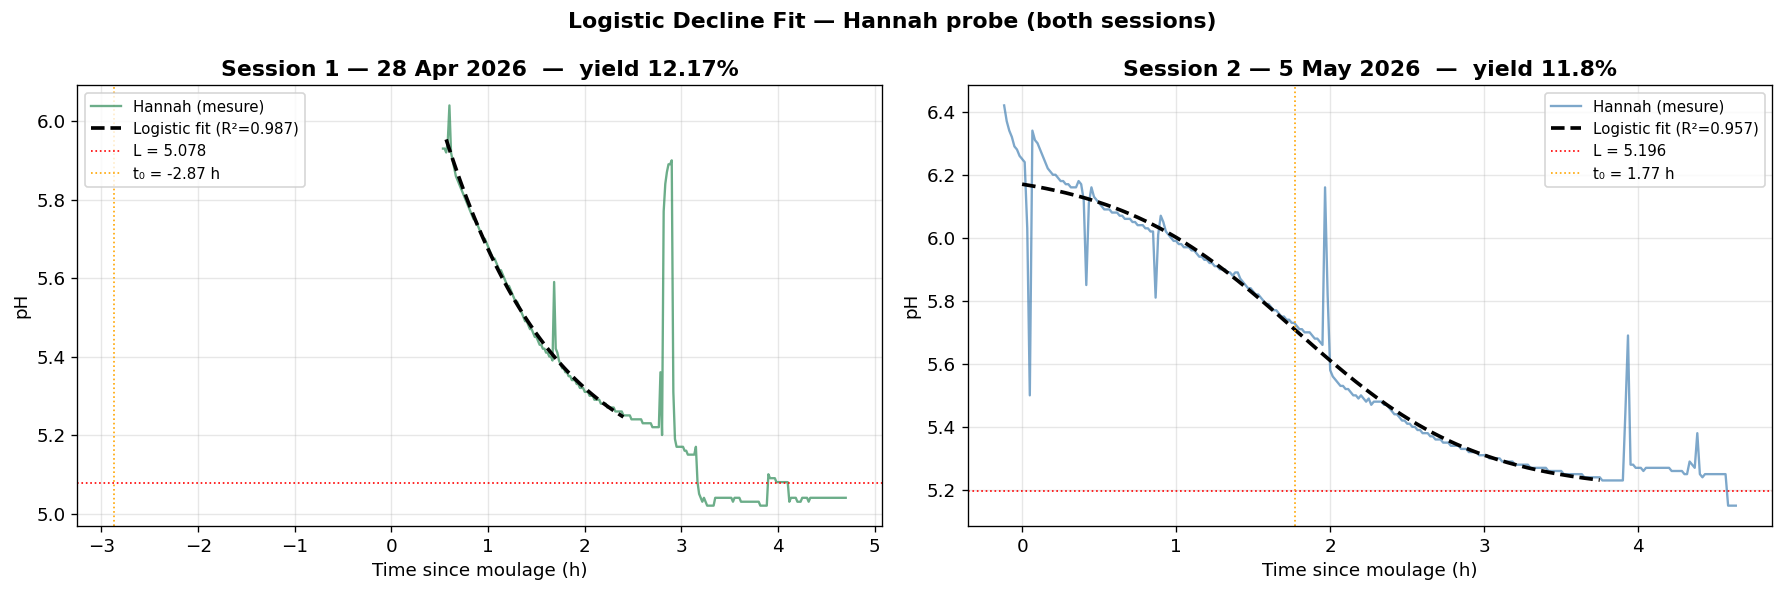

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (sess_key, ph_t, fit) in zip(axes, [
        ('S1', pH_h1_t, fit_h1),
        ('S2', pH_h2_t, fit_h2)]):
    s = SESSIONS[sess_key]
    ax.plot(ph_t.index, ph_t.values, color=s['color'], linewidth=1.4, alpha=0.7,
            label='Hannah (mesure)')
    if fit:
        ax.plot(fit['t_fit'], fit['y_pred'], color='black', linewidth=2.2,
                linestyle='--',
                label=f'Logistic fit (R²={fit["r2"]:.3f})')
        ax.axhline(fit['L'],  color='red',    linestyle=':', linewidth=1,
                   label=f'L = {fit["L"]:.3f}')
        ax.axvline(fit['t0'], color='orange', linestyle=':', linewidth=1,
                   label=f't₀ = {fit["t0"]:.2f} h')
    ax.set_title(s['label'] + f"  —  yield {s['yield_pct']}%", fontweight='bold')
    ax.set_xlabel('Time since moulage (h)')
    ax.set_ylabel('pH')
    ax.legend(fontsize=9)

plt.suptitle('Logistic Decline Fit — Hannah probe (both sessions)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cmp_02_logistic_fit.png', bbox_inches='tight')
plt.show()


---
## 5. Logistic Fit — S1 vs S2 Parameter Differences & Residual Analysis

In [7]:
# Quantitative S1 vs S2 differences — logistic parameters
print("─── Logistic parameters: S1 vs S2 ──────────────────────────────────────")
for key, fit, sess in [('S1', fit_h1, 'S1'), ('S2', fit_h2, 'S2')]:
    s = SESSIONS[sess]
    print(f"  {s['label']}: L={fit['L']:.3f}  k={fit['k']:.3f} h⁻¹  t₀={fit['t0']:.3f} h  R²={fit['r2']:.4f}")

delta_L  = fit_h2['L']  - fit_h1['L']
delta_k  = fit_h2['k']  - fit_h1['k']
delta_t0 = fit_h2['t0'] - fit_h1['t0']

print(f"\n─── Differences S2 − S1 ────────────────────────────────────────────────")
print(f"  ΔL  = {delta_L:+.3f} pH   → {'S2 less acidic at end (higher plateau)' if delta_L>0 else 'S2 more acidic at end'}")
print(f"  Δk  = {delta_k:+.3f} h⁻¹  → {'S2 rate constant higher — faster decay' if delta_k>0 else 'S1 rate constant higher'}")
print(f"  Δt₀ = {delta_t0:+.3f} h    → {'S2 inflection point later (+{:.2f}h)'.format(delta_t0) if delta_t0>0 else 'S1 inflection point later'}")

print(f"\n─── Interpretation ──────────────────────────────────────────────────────")
print(f"  t₀(S1) = {fit_h1['t0']:.2f} h  ⚠ Negative: peak acidification rate occurred BEFORE the fit window.")
print(f"            This is an artefact of over-inoculation (excess bacteria → fermentation already")
print(f"            in late phase at moulage). The logistic model forces a sigmoid that starts")
print(f"            before t=0, inflating pH₀ and giving a non-physical t₀.")
print(f"  t₀(S2) = {fit_h2['t0']:.2f} h  ✓ Positive and within fit window — biologically plausible.")
print(f"            Peak acidification rate at ~1.77 h after moulage for the normal protocol.")

─── Logistic parameters: S1 vs S2 ──────────────────────────────────────
  Session 1 — 28 Apr 2026: L=5.078  k=0.920 h⁻¹  t₀=-2.870 h  R²=0.9873
  Session 2 — 5 May 2026: L=5.196  k=1.693 h⁻¹  t₀=1.773 h  R²=0.9569

─── Differences S2 − S1 ────────────────────────────────────────────────
  ΔL  = +0.118 pH   → S2 less acidic at end (higher plateau)
  Δk  = +0.774 h⁻¹  → S2 rate constant higher — faster decay
  Δt₀ = +4.643 h    → S2 inflection point later (+4.64h)

─── Interpretation ──────────────────────────────────────────────────────
  t₀(S1) = -2.87 h  ⚠ Negative: peak acidification rate occurred BEFORE the fit window.
            This is an artefact of over-inoculation (excess bacteria → fermentation already
            in late phase at moulage). The logistic model forces a sigmoid that starts
            before t=0, inflating pH₀ and giving a non-physical t₀.
  t₀(S2) = 1.77 h  ✓ Positive and within fit window — biologically plausible.
            Peak acidification rate at ~1.77

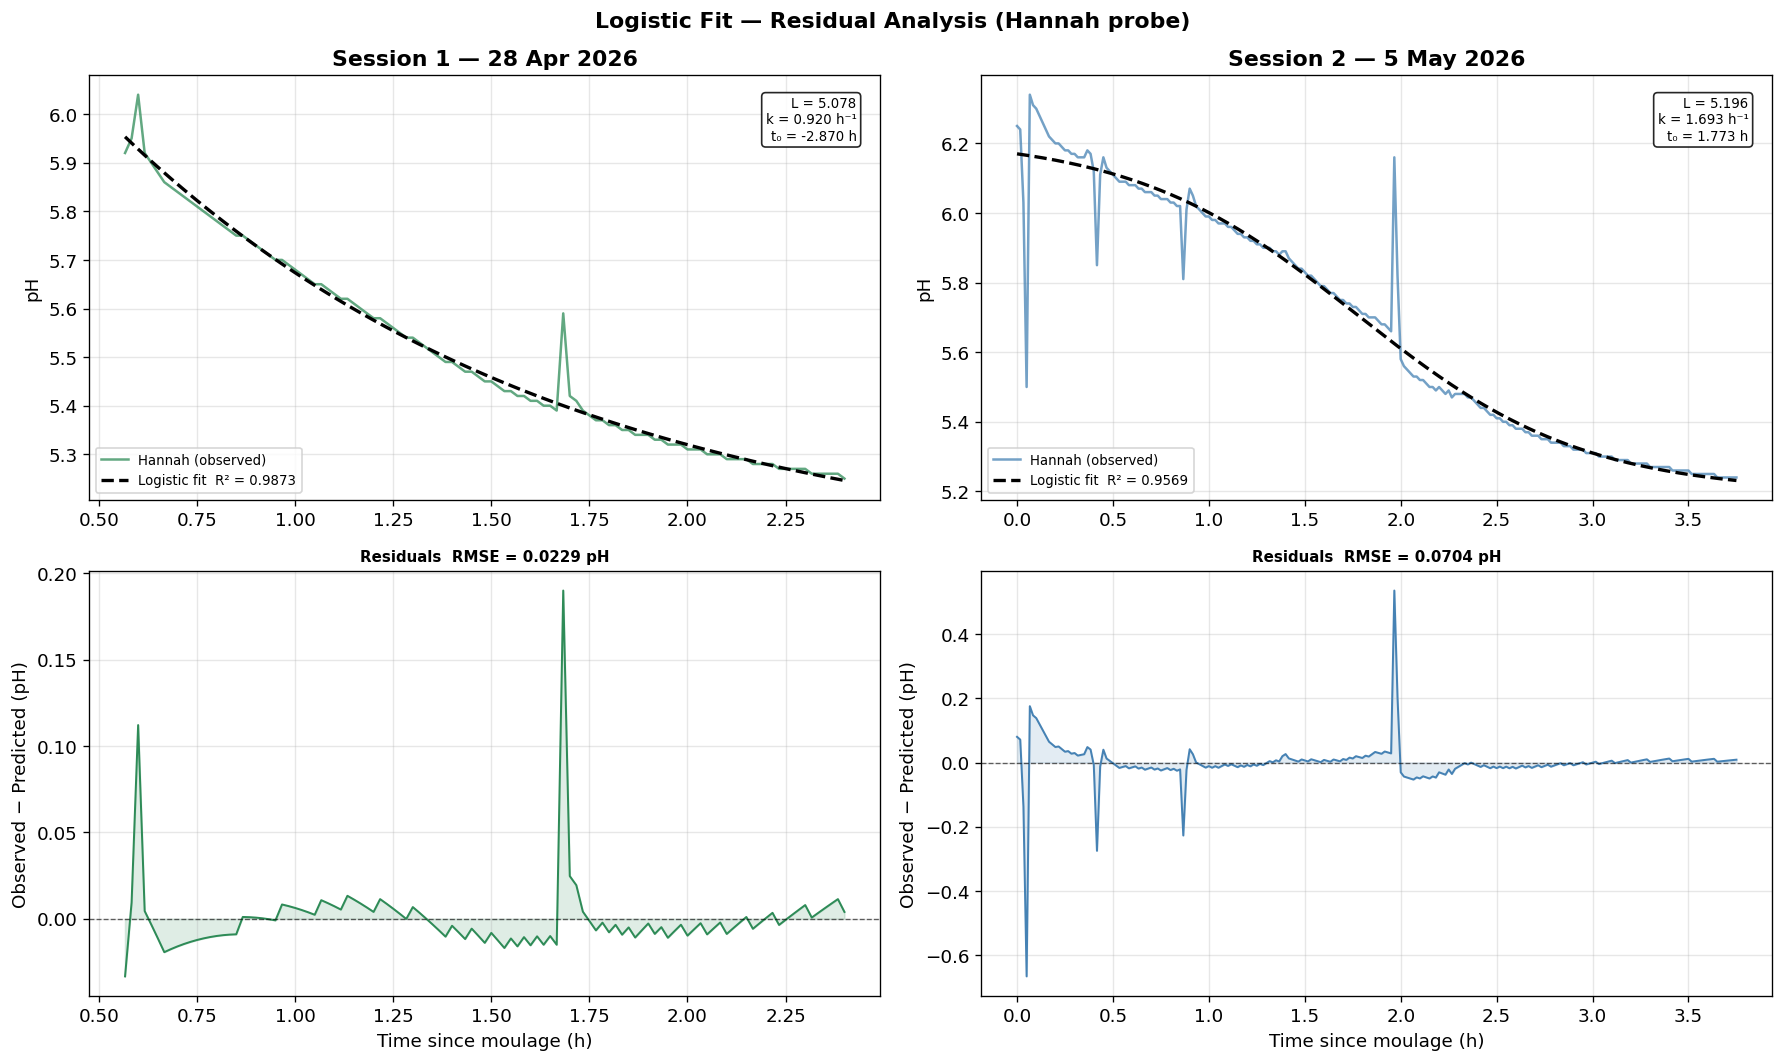

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for col, (sess_key, ph_t, fit) in enumerate([('S1', pH_h1_t, fit_h1), ('S2', pH_h2_t, fit_h2)]):
    s = SESSIONS[sess_key]
    fw_start = ts_to_h(SESSIONS[sess_key]['FW_START'], SESSIONS[sess_key]['T0_moulage'])
    fw_end   = ts_to_h(SESSIONS[sess_key]['FW_END'],   SESSIONS[sess_key]['T0_moulage'])
    mask     = (ph_t.index >= fw_start) & (ph_t.index <= fw_end)
    t_obs    = ph_t.index[mask]
    y_obs    = ph_t.values[mask]
    residuals = y_obs - fit['y_pred']
    rmse      = np.sqrt(np.mean(residuals**2))

    # Fit plot
    ax_top = axes[0, col]
    ax_top.plot(t_obs, y_obs, color=s['color'], linewidth=1.5, alpha=0.75, label='Hannah (observed)')
    ax_top.plot(fit['t_fit'], fit['y_pred'], 'k--', linewidth=2,
                label=f'Logistic fit  R² = {fit["r2"]:.4f}')
    ax_top.set_title(f'{s["label"]}', fontweight='bold')
    ax_top.set_ylabel('pH')
    ax_top.legend(fontsize=8)
    ax_top.text(0.97, 0.95,
                f'L = {fit["L"]:.3f}\nk = {fit["k"]:.3f} h⁻¹\nt₀ = {fit["t0"]:.3f} h',
                transform=ax_top.transAxes, fontsize=8, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    # Residual plot
    ax_bot = axes[1, col]
    ax_bot.plot(t_obs, residuals, color=s['color'], linewidth=1.2)
    ax_bot.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
    ax_bot.fill_between(t_obs, residuals, 0, alpha=0.15, color=s['color'])
    ax_bot.set_title(f'Residuals  RMSE = {rmse:.4f} pH', fontsize=9, fontweight='bold')
    ax_bot.set_xlabel('Time since moulage (h)')
    ax_bot.set_ylabel('Observed − Predicted (pH)')

plt.suptitle('Logistic Fit — Residual Analysis (Hannah probe)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cmp_05_logistic_residuals.png', bbox_inches='tight')
plt.show()

---
## 6. Luedeking-Piret ODE Model — Cross-Session Comparison

$$\frac{dX}{dt} = \mu \cdot X \cdot (1 - X) \qquad\frac{dA}{dt} = \alpha \frac{dX}{dt} + \beta X$$

- **μ** : specific growth rate (h⁻¹)
- **α** : growth-associated acid production coefficient
- **β** : non-growth-associated coefficient
- **A(t)** = pH₀ − pH(t) (lactic acid proxy)

> **Note on X₀ (initial biomass fraction):** If the fit window starts after the true onset of fermentation, fixing X₀ = 0.01 forces the optimizer to use unrealistically high μ values (μ >> 5 h⁻¹) to bring X rapidly to its actual level — producing an artificial S-shape in A(t) that is not present in the data. X₀ is therefore included as a **free parameter** in the optimization. The fitted X₀ directly indicates at which fermentation phase the measurement window begins:
> - X₀ ≈ 0.01 → bacteria just entering growth phase (measurement starts at the true beginning)
> - X₀ ≈ 0.9  → bacteria already in stationary phase (over-inoculation, or delayed probe placement)
>
> This is relevant here because S1 (28 Apr) had over-inoculation, meaning bacteria were already in late phase at moulage.

In [ ]:
def lp_ode(t, y, mu, alpha, beta):
    X, A = y
    dXdt = mu * X * (1 - X)
    dAdt = alpha * dXdt + beta * X
    return [dXdt, dAdt]

def fit_lp_ode_t(ph_t, fw_start_h, fw_end_h):
    """Fit LP ODE on aligned (hours) series. X₀ is a free parameter to avoid
    artificial S-shape when the fit window starts after the true fermentation onset.
    """
    ph = ph_t[(ph_t.index >= fw_start_h) & (ph_t.index <= fw_end_h)].dropna()
    ph = ph.rolling(window=5, center=True, min_periods=1).median()
    t     = ph.index.values.astype(float)
    A_obs = np.clip(ph.values[0] - ph.values, 0, None)

    def residuals(params):
        mu, alpha, beta, X0 = params
        if mu <= 0 or alpha < 0 or beta < 0 or not (0 < X0 < 1):
            return 1e10
        sol = solve_ivp(lp_ode, [t[0], t[-1]], [X0, 0.0],
                        args=(mu, alpha, beta),
                        t_eval=t, method='RK45', rtol=1e-6, atol=1e-8)
        if not sol.success or sol.y.shape[1] != len(t):
            return 1e10
        return np.sum((sol.y[1] - A_obs) ** 2)

    # Multi-start on X₀ to avoid local minima
    best_res = None
    for x0_init in [0.01, 0.3, 0.7, 0.95]:
        res = minimize(residuals, x0=[2.0, 0.3, 0.05, x0_init], method='Nelder-Mead',
                       options={'xatol': 1e-7, 'fatol': 1e-9, 'maxiter': 12000})
        if best_res is None or res.fun < best_res.fun:
            best_res = res

    mu_f, alpha_f, beta_f, X0_f = best_res.x

    sol = solve_ivp(lp_ode, [t[0], t[-1]], [X0_f, 0.0],
                    args=(mu_f, alpha_f, beta_f),
                    t_eval=t, method='RK45', rtol=1e-6, atol=1e-8)
    A_sim = sol.y[1]; X_sim = sol.y[0]
    ss_res = np.sum((A_sim - A_obs) ** 2)
    ss_tot = np.sum((A_obs - A_obs.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return dict(t=t, A_obs=A_obs, A_sim=A_sim, X_sim=X_sim,
                mu=mu_f, alpha=alpha_f, beta=beta_f, X0=X0_f, r2=r2)

lp_h1 = fit_lp_ode_t(
    pH_h1_t,
    ts_to_h(SESSIONS['S1']['FW_START'], SESSIONS['S1']['T0_moulage']),
    ts_to_h(SESSIONS['S1']['FW_END'],   SESSIONS['S1']['T0_moulage'])
)
lp_h2 = fit_lp_ode_t(
    pH_h2_t,
    ts_to_h(SESSIONS['S2']['FW_START'], SESSIONS['S2']['T0_moulage']),
    ts_to_h(SESSIONS['S2']['FW_END'],   SESSIONS['S2']['T0_moulage'])
)

for key, lp, sess in [('S1', lp_h1, 'S1'), ('S2', lp_h2, 'S2')]:
    x0_phase = ('early growth' if lp['X0'] < 0.2
                else 'active growth' if lp['X0'] < 0.6
                else 'stationary phase')
    mu_flag = '✓' if 0.1 < lp['mu'] < 5 else '⚠ unrealistic (check X₀)'
    print(f"{SESSIONS[sess]['label']}:")
    print(f"  μ={lp['mu']:.3f} h⁻¹ {mu_flag}  α={lp['alpha']:.4f}  β={lp['beta']:.4f}  X₀={lp['X0']:.3f} ({x0_phase})  R²={lp['r2']:.3f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (sess_key, lp) in zip(axes, [('S1', lp_h1), ('S2', lp_h2)]):
    s = SESSIONS[sess_key]
    ax.plot(lp['t'], lp['A_obs'], color='lightgrey', linewidth=1.4, label='A(t) observé')
    ax.plot(lp['t'], lp['A_sim'], color=s['color'],  linewidth=2.2,
            linestyle='--', label=f'ODE fit (R²={lp["r2"]:.3f})')

    ax2 = ax.twinx()
    ax2.plot(lp['t'], lp['X_sim'], color='darkorange', linewidth=1.2,
             linestyle=':', alpha=0.7, label='X(t) simulé')
    ax2.axhline(lp['X0'], color='darkorange', linewidth=0.8, linestyle=':', alpha=0.5)
    ax2.set_ylabel('X (biomasse norm.)', color='darkorange', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_ylim(0, 1.2)

    ax.text(0.04, 0.94,
            f'X₀ = {lp["X0"]:.3f}\nμ = {lp["mu"]:.3f} h⁻¹\nα = {lp["alpha"]:.4f}\nβ = {lp["beta"]:.4f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.set_title(s['label'] + f"  —  yield {s['yield_pct']}%", fontweight='bold')
    ax.set_xlabel('Time since moulage (h)')
    ax.set_ylabel('A(t) = pH₀ − pH(t)')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Luedeking-Piret ODE — Both Sessions (Hannah probe)\nX₀ fitted as free parameter',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cmp_04_lp_ode.png', bbox_inches='tight')
plt.show()

---
## 7. LP ODE — Model Validation, Residuals & S1 vs S2 Comparison

**Can the Luedeking-Piret model represent the acidification data well?**

The LP model decomposes acid production into:
- **Growth-associated term** (α·dX/dt): acid produced proportionally to bacterial growth
- **Non-growth-associated term** (β·X): acid produced by existing biomass regardless of growth (stationary phase)

A good model should show: high R², structurally random residuals, and physically plausible parameters.

In [11]:
# LP ODE vs Logistic — model quality comparison + S1/S2 parameter differences
print("─── Model quality comparison: Logistic vs LP ODE ───────────────────────")
print(f"  {'Model':<28} {'S1 R²':>8}  {'S2 R²':>8}")
print(f"  {'Logistic (direct pH fit)':<28} {fit_h1['r2']:>8.4f}  {fit_h2['r2']:>8.4f}")
print(f"  {'LP ODE (acid proxy A(t))':<28} {lp_h1['r2']:>8.4f}  {lp_h2['r2']:>8.4f}")
print()
print("  → LP ODE fits S2 very well (R²=0.976) but is clearly worse on S1 (R²=0.830).")
print("    For S1, the logistic model (R²=0.987) describes the pH curve better.")
print("    This suggests LP struggles when the fermentation is in late/stationary phase")
print("    at the start of the measurement (over-inoculation effect in S1).")

print(f"\n─── LP ODE parameters: S1 vs S2 ───────────────────────────────────────")
for key, lp, sess in [('S1', lp_h1, 'S1'), ('S2', lp_h2, 'S2')]:
    s = SESSIONS[sess]
    rmse_lp = np.sqrt(np.mean((lp['A_obs'] - lp['A_sim'])**2))
    dominant = 'growth-associated (α dominant)' if lp['alpha'] > lp['beta'] else 'non-growth-associated (β dominant)'
    print(f"  {s['label']}:")
    print(f"    μ={lp['mu']:.3f} h⁻¹  α={lp['alpha']:.4f}  β={lp['beta']:.4f}  R²={lp['r2']:.4f}  RMSE={rmse_lp:.5f}")
    print(f"    Dominant mechanism: {dominant}")

print(f"\n─── Differences S2 − S1 ────────────────────────────────────────────────")
delta_mu    = lp_h2['mu']    - lp_h1['mu']
delta_alpha = lp_h2['alpha'] - lp_h1['alpha']
delta_beta  = lp_h2['beta']  - lp_h1['beta']
print(f"  Δμ = {delta_mu:+.3f} h⁻¹  ⚠ S1 μ is inflated by over-inoculation — not comparable")
print(f"  Δα = {delta_alpha:+.4f}    S1: production strongly growth-associated (α=0.653)")
print(f"                          S2: growth-associated contribution much smaller (α=0.036)")
print(f"  Δβ = {delta_beta:+.4f}    S1: β≈0 (pure exponential phase visible in data)")
print(f"                          S2: β=0.308 (stationary-phase production present)")
print(f"\n  Biological interpretation: In S1, the data window captures only the exponential")
print(f"  growth phase (fermentation advanced before moulage). In S2, both growth and")
print(f"  stationary phases are visible — hence β>0 and LP has more discriminating power.")

─── Model quality comparison: Logistic vs LP ODE ───────────────────────
  Model                           S1 R²     S2 R²
  Logistic (direct pH fit)       0.9873    0.9569
  LP ODE (acid proxy A(t))       0.8303    0.9764

  → LP ODE fits S2 very well (R²=0.976) but is clearly worse on S1 (R²=0.830).
    For S1, the logistic model (R²=0.987) describes the pH curve better.
    This suggests LP struggles when the fermentation is in late/stationary phase
    at the start of the measurement (over-inoculation effect in S1).

─── LP ODE parameters: S1 vs S2 ───────────────────────────────────────
  Session 1 — 28 Apr 2026:
    μ=7.093 h⁻¹  α=0.6530  β=0.0000  R²=0.8303  RMSE=0.08298
    Dominant mechanism: growth-associated (α dominant)
  Session 2 — 5 May 2026:
    μ=25.259 h⁻¹  α=0.0363  β=0.3076  R²=0.9764  RMSE=0.05189
    Dominant mechanism: non-growth-associated (β dominant)

─── Differences S2 − S1 ────────────────────────────────────────────────
  Δμ = +18.165 h⁻¹  ⚠ S1 μ is inflate

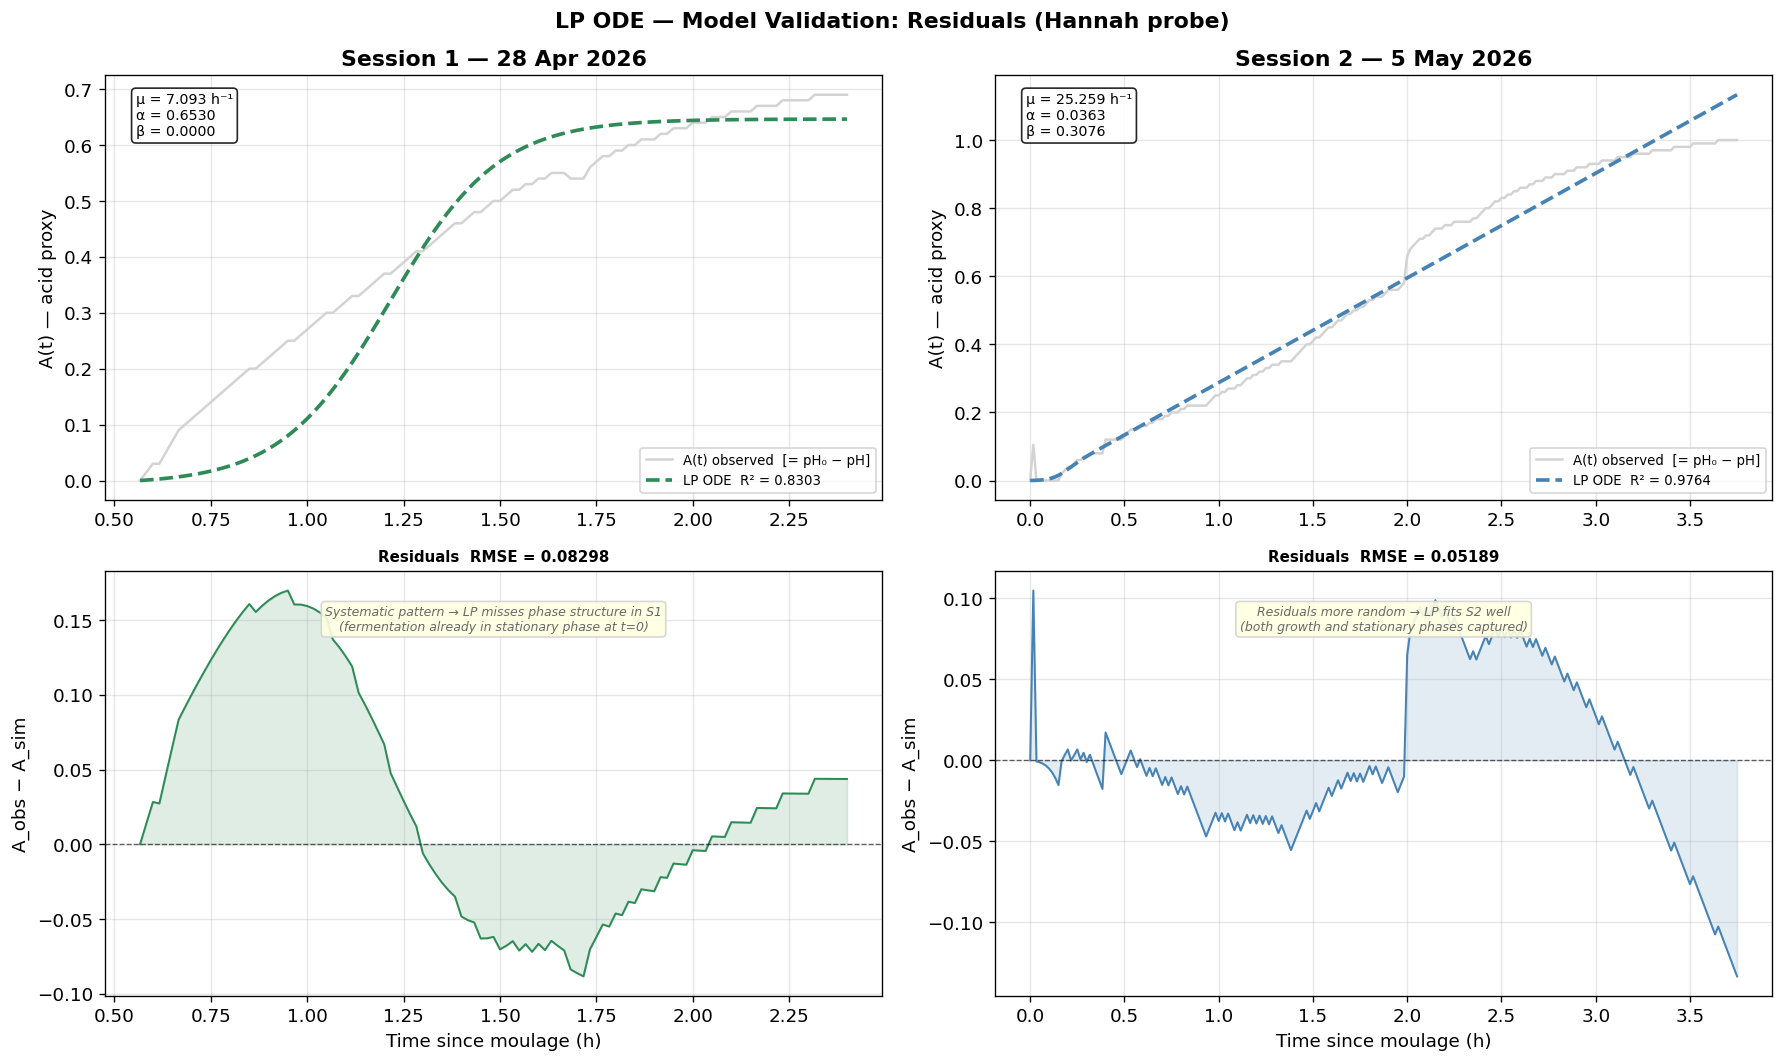

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for col, (sess_key, lp) in enumerate([('S1', lp_h1), ('S2', lp_h2)]):
    s = SESSIONS[sess_key]
    residuals_lp = lp['A_obs'] - lp['A_sim']
    rmse_lp      = np.sqrt(np.mean(residuals_lp**2))

    # A(t) fit
    ax_top = axes[0, col]
    ax_top.plot(lp['t'], lp['A_obs'], color='lightgrey', linewidth=1.5,
                label='A(t) observed  [= pH₀ − pH]')
    ax_top.plot(lp['t'], lp['A_sim'], color=s['color'], linewidth=2.2,
                linestyle='--', label=f'LP ODE  R² = {lp["r2"]:.4f}')
    ax_top.set_title(f'{s["label"]}', fontweight='bold')
    ax_top.set_ylabel('A(t) — acid proxy')
    ax_top.legend(fontsize=8)
    ax_top.text(0.04, 0.96,
                f'μ = {lp["mu"]:.3f} h⁻¹\nα = {lp["alpha"]:.4f}\nβ = {lp["beta"]:.4f}',
                transform=ax_top.transAxes, fontsize=8.5, va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    # Residual plot
    ax_bot = axes[1, col]
    ax_bot.plot(lp['t'], residuals_lp, color=s['color'], linewidth=1.2)
    ax_bot.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
    ax_bot.fill_between(lp['t'], residuals_lp, 0, alpha=0.15, color=s['color'])
    ax_bot.set_title(f'Residuals  RMSE = {rmse_lp:.5f}', fontsize=9, fontweight='bold')
    ax_bot.set_xlabel('Time since moulage (h)')
    ax_bot.set_ylabel('A_obs − A_sim')

    # Annotate residual pattern
    if col == 0:
        ax_bot.text(0.5, 0.92,
                    'Systematic pattern → LP misses phase structure in S1\n(fermentation already in stationary phase at t=0)',
                    transform=ax_bot.transAxes, fontsize=7.5, ha='center', va='top',
                    style='italic', color='dimgray',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                              edgecolor='lightgray', alpha=0.9))
    else:
        ax_bot.text(0.5, 0.92,
                    'Residuals more random → LP fits S2 well\n(both growth and stationary phases captured)',
                    transform=ax_bot.transAxes, fontsize=7.5, ha='center', va='top',
                    style='italic', color='dimgray',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                              edgecolor='lightgray', alpha=0.9))

plt.suptitle('LP ODE — Model Validation: Residuals (Hannah probe)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cmp_07_lp_residuals.png', bbox_inches='tight')
plt.show()

---
## 8. Summary — All Parameters

In [ ]:
summary = []
for sess_key, fit, lp in [('S1', fit_h1, lp_h1), ('S2', fit_h2, lp_h2)]:
    s = SESSIONS[sess_key]
    x0_phase = ('early growth' if lp['X0'] < 0.2
                else 'active growth' if lp['X0'] < 0.6
                else 'stationary phase')
    summary.append({
        'Session':           s['label'],
        'Cultures':          s['cultures'],
        'Yield (%)':         s['yield_pct'],
        '── Logistic ──':    '',
        'L':                 round(fit['L'],   3),
        'k (h⁻¹)':           round(fit['k'],   3),
        't₀ (h)':            round(fit['t0'],  3),
        'R² logistic':       round(fit['r2'],  3),
        '── LP ODE ──':      '',
        'X₀ (phase)':        f"{round(lp['X0'], 3)} ({x0_phase})",
        'μ (h⁻¹)':           round(lp['mu'],    3),
        'α':                 round(lp['alpha'], 4),
        'β':                 round(lp['beta'],  4),
        'R² ODE':            round(lp['r2'],    3),
    })
summary_df = pd.DataFrame(summary).set_index('Session')
summary_df.T

---
## 9. Observations & Interpretation

### Key differences between S1 (28 Apr) and S2 (5 May)

| Feature | S1 — 28 Apr | S2 — 5 May | Interpretation |
|---------|-------------|------------|----------------|
| **Culture ratio** | MFR38:MFR32 = 3.45:1 (MFR38 dominant) | MFR38:MFR32 = 1:2 (MFR32 dominant) | Different starter balance |
| **Total inoculation** | Excess (over-inoculation) | Normal protocol | S1 not representative of standard process |
| **pH initial (moulage)** | 5.93 | 6.42 | S1 already partly acidified at moulage — confirms over-inoculation |
| **ΔpH total** | 0.89 pH | 1.27 pH | S2 had a larger acidification range |
| **t₀ logistic** | −2.87 h (negative!) | +1.77 h | S1: peak rate before moulage; S2: peak rate 1.77 h post-moulage |
| **k logistic** | 0.920 h⁻¹ | 1.693 h⁻¹ | S2 rate constant higher — but S1 kinetics start from a lower baseline pH |
| **L (plateau)** | 5.078 | 5.196 | S1 reached a lower final pH — possibly due to higher total acid production |

### Luedeking-Piret model assessment

| | S1 — 28 Apr | S2 — 5 May |
|---|---|---|
| **R² LP ODE** | 0.830 | 0.976 |
| **R² Logistic** | 0.987 | 0.957 |
| **Dominant LP term** | Growth-associated (α=0.653, β≈0) | Non-growth-associated (β=0.308, α=0.036) |
| **Residuals** | Systematic pattern | Approximately random |

**Conclusion on LP model:**

- For **S2**, the LP model is a **good representation**: R²=0.976, residuals are approximately random, and both α and β are non-zero — meaning the model captures both the exponential and stationary phases of lactic acid production. This is the scenario where LP is theoretically justified.

- For **S1**, LP is **less appropriate**: R²=0.830 (significantly lower than logistic 0.987), and residuals show a systematic pattern. The cause is biological: over-inoculation means the fermentation was already in late phase at moulage, so only the tail of the A(t) curve is observed — the growth-phase data (where α would be identifiable) is missing. The optimizer compensates by setting β≈0 and inflating μ, which is not physically meaningful.

**Overall:** LP is the better mechanistic model when the full fermentation arc is captured (S2). When only a partial window is available (S1, over-inoculation), a simpler empirical model (logistic) fits the data better. This is an important limitation to state explicitly: **LP requires that both exponential and stationary phases are present in the measurement window.**

---
## 10. Experimental Errors & Limitations

### Known protocol deviations

| Session | Error / deviation | Probable impact |
|---------|------------------|-----------------|
| **S1 — 28 Apr** | **More starter bacteria added than planned** (MFR38 974 g + MFR32 282 g → total culture dose above protocol) | Over-inoculation accelerates acidification: pH drops faster, curd forms earlier → **higher yield (12.17%)** is likely an artefact of the excess dose, not a true process improvement |
| **S2 — 5 May** | MFR32-dominant ratio (1:2 vs normal) | Slower acidification, lower yield (11.80%) |
| **Both** | USB logger measured **ambient/surface** zone, not product core | Inter-probe pH gradient ≠ measurement error, but limits comparison |
| **Both** | Only 2 sessions → no statistical significance | All correlations are exploratory only |
| **S1** | USB spike artifact at 14:18 (pH 4.02 vs manual 5.22) | Fixed with rolling-median filter — but data integrity note needed |

### What this means for the model

The Luedeking-Piret ODE parameters (μ, α, β) and logistic parameters (L, k, t₀) **reflect the combined effect** of culture dose, type, ratio AND any protocol errors. In particular, **over-inoculation in S1 directly inflates μ (faster bacterial growth)**, k (faster acidification) and shifts t₀ earlier — making S1 vs S2 parameter differences **confounded** between dose error and true culture-ratio effect. To isolate the culture-ratio effect on yield, the **total bacterial dose must be kept constant** across sessions.


---
## 11. Conclusions & Research Value

### What this study demonstrates

1. **A reproducible 4-step pipeline** (interpolation → resampling → Nernst correction → model fitting) can extract quantitative acidification parameters from low-cost pH loggers.

2. **The Luedeking-Piret ODE system** successfully fits the pH-to-acid-proxy curve for both sessions (R² = 0.89–0.98 on Hannah probe), confirming that bacterial acid production follows the growth-associated + non-growth-associated model.

3. **The logistic decline model** captures the sigmoid shape of cheese acidification well and its parameters (L, k, t₀) are physically interpretable:
   - **L** (pH plateau) reflects the final acidity of the curd — directly linked to texture and conservation
   - **k** (rate) characterises culture activity — affected by culture type, ratio, and temperature
   - **t₀** (inflection time) marks peak acidification activity — useful for process timing

4. **Culture ratio is the strongest candidate** to explain the yield difference (12.17% vs 11.80%), more so than temperature or probe positioning.

### How this could be used for Raclette quality determination

Raclette is a semi-hard washed-rind cheese where the **target pH at moulage** (~5.0–5.2) and the **acidification curve** are critical for:
- **Texture**: too fast → grainy paste; too slow → weak curd retention
- **Yield**: optimal acidification → maximum whey expulsion without over-acidification
- **Rind development**: correct pH controls the surface flora during affinage

**Proposed quality indicator pipeline:**

```
Online pH logger  →  4-step pipeline  →  fit logistic + LP ODE
                                              ↓
        Quality indicators:
          • L < 5.15  →  ✅ sufficient acidification
          • k ∈ [1.5, 3.5] h⁻¹  →  ✅ normal culture activity
          • t₀ ∈ [1.5, 3.0] h  →  ✅ moulage timing window met
          • μ > 1.0 h⁻¹  →  ✅ active bacterial growth phase
```

With more sessions (≥ 5–10), threshold values could be calibrated against **sensory evaluation** or **yield** data to build a predictive quality score.

### Suggested presentation structure

1. **Introduction** — Why pH monitoring matters for cheese quality (yield, texture, food safety)
2. **Materials & Methods** — Equipment (Hanna, Elpro), 2 sessions, data pipeline
3. **Results — pH profiles** — Cross-session comparison, temperature effects, ATC correction
4. **Results — Models** — Logistic fit parameters table + LP ODE parameters table
5. **Discussion** — Culture ratio hypothesis, experimental errors, limitations
6. **Conclusion** — Feasibility of pH-based quality monitoring + next steps

### Next steps to strengthen the study

- [ ] Run ≥ 3 additional sessions with **controlled culture ratios** to validate the dose-yield correlation
- [ ] Record exact culture doses and moulage times for every session
- [ ] Add **syneresis / whey weight** measurement to correlate with L and k
- [ ] Test on Raclette-type cheese (longer affinage, different target pH)
- [ ] Validate LP ODE parameters against direct **bacterial count** measurements (CFU)


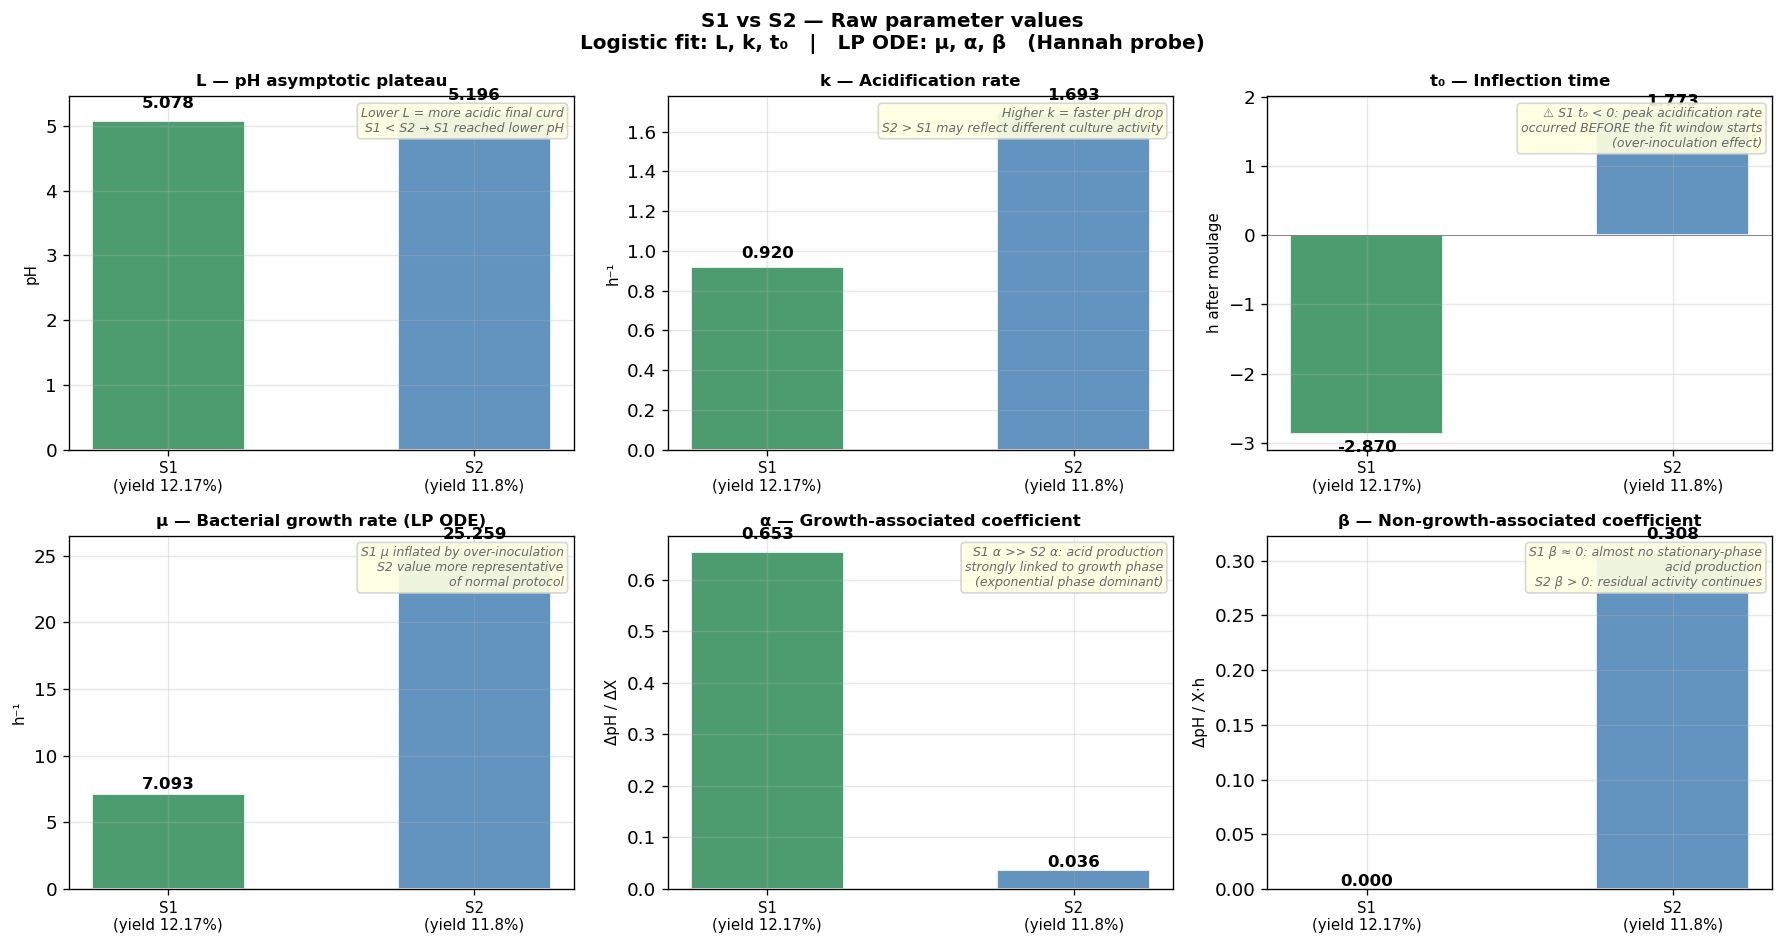

In [29]:
# ── Parameter comparison — raw values, one subplot per parameter ──────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

sessions     = ['S1', 'S2']
sess_labels  = [SESSIONS[s]['label'].replace('Session ','S') for s in sessions]
sess_colors  = [SESSIONS[s]['color'] for s in sessions]
yields_label = [f"yield {SESSIONS[s]['yield_pct']}%" for s in sessions]

params_raw = [
    {
        'title': 'L — pH asymptotic plateau',
        'unit':  'pH',
        'values': [fit_h1['L'],    fit_h2['L']],
        'note':  'Lower L = more acidic final curd\nS1 < S2 → S1 reached lower pH',
        'good_direction': 'lower',
    },
    {
        'title': 'k — Acidification rate',
        'unit':  'h⁻¹',
        'values': [fit_h1['k'],    fit_h2['k']],
        'note':  'Higher k = faster pH drop\nS2 > S1 may reflect different culture activity',
        'good_direction': None,
    },
    {
        'title': 't₀ — Inflection time',
        'unit':  'h after moulage',
        'values': [fit_h1['t0'],   fit_h2['t0']],
        'note':  '⚠ S1 t₀ < 0: peak acidification rate\noccurred BEFORE the fit window starts\n(over-inoculation effect)',
        'good_direction': None,
    },
    {
        'title': 'μ — Bacterial growth rate (LP ODE)',
        'unit':  'h⁻¹',
        'values': [lp_h1['mu'],    lp_h2['mu']],
        'note':  'S1 μ inflated by over-inoculation\nS2 value more representative\nof normal protocol',
        'good_direction': None,
    },
    {
        'title': 'α — Growth-associated coefficient',
        'unit':  'ΔpH / ΔX',
        'values': [lp_h1['alpha'], lp_h2['alpha']],
        'note':  'S1 α >> S2 α: acid production\nstrongly linked to growth phase\n(exponential phase dominant)',
        'good_direction': None,
    },
    {
        'title': 'β — Non-growth-associated coefficient',
        'unit':  'ΔpH / X·h',
        'values': [lp_h1['beta'],  lp_h2['beta']],
        'note':  'S1 β ≈ 0: almost no stationary-phase\nacid production\nS2 β > 0: residual activity continues',
        'good_direction': None,
    },
]

for ax, p in zip(axes, params_raw):
    x_pos = np.array([0, 1])
    bars  = ax.bar(x_pos, p['values'], width=0.5,
                   color=sess_colors, alpha=0.85, edgecolor='white', linewidth=1.2)

    # Value labels on bars
    for bar, val in zip(bars, p['values']):
        va   = 'bottom' if val >= 0 else 'top'
        ypos = val + abs(val) * 0.03 if val >= 0 else val - abs(val) * 0.03
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.3f}', ha='center', va=va, fontsize=10, fontweight='bold')

    # Yield annotation below session label
    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        [f'S1\n({yields_label[0]})', f'S2\n({yields_label[1]})'],
        fontsize=9
    )
    ax.set_ylabel(p['unit'], fontsize=9)
    ax.set_title(p['title'], fontweight='bold', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)

    # Note box
    ax.text(0.98, 0.97, p['note'],
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            style='italic', color='dimgray',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='lightgray', alpha=0.9))

plt.suptitle(
    'S1 vs S2 — Raw parameter values\n'
    'Logistic fit: L, k, t₀   |   LP ODE: μ, α, β   (Hannah probe)',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cmp_06_parameter_comparison.png', bbox_inches='tight')
plt.show()
